In [1]:
import json

import pandas as pd
import numpy as np
import ast
import os

from typing import Union, List

# Load Impact DF

In [2]:
def try_literal_eval(x):
    if isinstance(x, str):
        x = x.strip()
        if (x.startswith("[") and x.endswith("]")) or \
           (x.startswith("{") and x.endswith("}")) or \
           (x.startswith("(") and x.endswith(")")):
            try:
                return ast.literal_eval(x)
            except (ValueError, SyntaxError):
                return x
    return x

In [3]:
dataset_dir = "/home/yishin/keith/patent_research/model_io"

In [4]:
Impact_df = pd.read_csv(os.path.join(dataset_dir, "3_Impact_Sub_Regions.csv"), encoding="utf-8")
Impact_df = Impact_df.map(try_literal_eval)

Impact_df.head()

,title,caption,image_paths,best_fig_desc,Loc_class,main_class,sub_class,first_class,crop_paths,bbox
0,Snack food product,"The image is a rectangular shape, and it is a ...",[impact_dataset/2017/USD0787150-20170523/USD07...,{'FIG. 1': 'FIG. 1 is a perspective view of a ...,"{01-01, 11-01}",1,1,01-01,"[figure_crops/0_Snack food product/FIG_4.jpg, ...","{'FIG_4': [{'id': 0, 'bbox': (43, 42, 1739, 27..."
1,Ring-like input device,The image is a square-shaped drawing of a ring...,[impact_dataset/2013/USD0673953-20130108/USD06...,{'FIG. 1': 'FIG. 1 is a perspective view of a ...,"{14-02, 01-01, 11-01}",1,1,01-01,[figure_crops/1_Ring-like input device/FIG_2.j...,"{'FIG_2': [{'id': 0, 'bbox': (4, 0, 1140, 1514..."
2,Snack food,The image is a black and white drawing of a sn...,[impact_dataset/2016/USD0752316-20160329/USD07...,"{'FIG. 2': 'FIG. 2 is a perspective view.', 'F...","{01-01, 11-01}",1,1,01-01,[],{}
3,Food bar,"The image is square-shaped, and it is a food b...",[impact_dataset/2019/USD0862830-20191015/USD08...,{'FIG. 5': 'FIG. 5 is a front elevation view o...,{01-01},1,1,01-01,"[figure_crops/3_Food bar/FIG_4.jpg, figure_cro...","{'FIG_4': [{'id': 1, 'bbox': (0, 2, 700, 439),..."
4,Bracelet,"The image is a white outline of a bracelet, wh...",[impact_dataset/2018/USD0830218-20181009/USD08...,{'FIG. 1': 'FIG. 1 is a front perspective view...,"{01-01, 11-01}",1,1,01-01,"[figure_crops/4_Bracelet/FIG_2.jpg, figure_cro...","{'FIG_2': [{'id': 5, 'bbox': (0, 4, 1874, 394)..."


# Test idx

In [86]:
idx = 499
# idx = 500

idx_row = Impact_df.iloc[idx]
title = idx_row["title"]
caption = idx_row["caption"]
crops = idx_row["crop_paths"]
bbox = idx_row["bbox"]

# Keyword Generation

In [6]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info
import torch

QWEN_MODEL = "Qwen/Qwen2.5-VL-7B-Instruct"

qwen_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    QWEN_MODEL,
    torch_dtype=torch.bfloat16,
    attn_implementation="eager",
    device_map="auto",
).eval()

qwen_processor = AutoProcessor.from_pretrained(
    QWEN_MODEL,
    min_pixels=256 * 28 * 28,
    max_pixels=768 * 28 * 28,
)

/home/yishin/miniconda3/envs/patent_qwen/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading checkpoint shards: 100%|██████████| 5/5 [00:04<00:00,  1.14it/s]
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [7]:
def generate_part_keywords_qwen(
    image_path,
    title,
    caption=None,
    model=qwen_model,
    processor=qwen_processor,
    max_new_tokens=200,
):
    """
    Generate candidate part keywords for GroundingDINO, grounded in the
    actual image content (not generic prior knowledge about the object class).
    """
    instructions = (
        f"This is a figure from a design patent titled \"{title}\".\n"
    )
    if caption:
        instructions += f"Existing caption for this image: \"{caption}\"\n"

    instructions += (
        "\nList the distinct named parts or components that are visibly "
        "depicted in this specific image. Rules:\n"
        "- One part per line, no numbering, no bullets\n"
        "- Short noun phrases only (1-3 words)\n"
        "- No adjectives about color, material, or style\n"
        "- Only list parts you can actually see in this image, not parts "
        f"a {title} typically has\n"
        "- Do not use generic words like 'part', 'component', 'section', 'piece'\n"
        "- If a part is only partially visible or ambiguous, skip it"
    )

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": instructions},
            ],
        }
    ]

    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    ).to(model.device)

    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]

    raw_keywords = [
        line.strip("-•* ").strip()
        for line in output_text.split("\n")
        if line.strip()
    ]

    # basic cleanup: drop the forbidden generic terms if the model ignored the instruction
    banned = {"part", "component", "section", "piece"}
    raw_keywords = [kw for kw in raw_keywords if kw.lower() not in banned]

    return raw_keywords

In [32]:
keywords = generate_part_keywords_qwen(
    image_path=crops[0],
    title=title,
    caption=caption,
)
print(keywords)

/home/yishin/miniconda3/envs/patent_qwen/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `1e-06` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(


['Seat', 'Backrest', 'Legs', 'Smiley face', 'Holes', 'Straps']


# GroundingDINO V2

In [59]:
import torch
from transformers import (
    AutoProcessor,
    AutoModelForZeroShotObjectDetection
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

GROUNDING_DINO_MODEL = "IDEA-Research/grounding-dino-base"

gdino_processor = AutoProcessor.from_pretrained(
    GROUNDING_DINO_MODEL
)

gdino_model = AutoModelForZeroShotObjectDetection.from_pretrained(
    GROUNDING_DINO_MODEL
).to(DEVICE)

gdino_model.eval()

GroundingDinoForObjectDetection(
  (model): GroundingDinoModel(
    (backbone): GroundingDinoConvModel(
      (conv_encoder): GroundingDinoConvEncoder(
        (model): SwinBackbone(
          (embeddings): SwinEmbeddings(
            (patch_embeddings): SwinPatchEmbeddings(
              (projection): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
            )
            (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (encoder): SwinEncoder(
            (layers): ModuleList(
              (0): SwinStage(
                (blocks): ModuleList(
                  (0): SwinLayer(
                    (layernorm_before): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
                    (attention): SwinAttention(
                      (self): SwinSelfAttention(
                        (query): Linear(in_features=128, out_features=128, bias=True)
                        (key): Linear(in_featu

In [60]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from PIL import Image

In [61]:
def show_grounding_dino_results(
    results,
    cols=2,
    figsize_per_image=8,
):
    """
    Display Grounding DINO detections over each original image.
    """

    items = list(results.items())

    if not items:
        print("No results to display.")
        return

    rows = math.ceil(len(items) / cols)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(
            cols * figsize_per_image,
            rows * figsize_per_image
        )
    )

    axes = np.atleast_1d(axes).flatten()

    for ax, (fig_name, figure_result) in zip(axes, items):
        image = Image.open(
            figure_result["image_path"]
        ).convert("RGB")

        ax.imshow(image)

        for detection in figure_result["detections"]:
            x1, y1, x2, y2 = detection["bbox"]

            ax.add_patch(
                Rectangle(
                    (x1, y1),
                    x2 - x1,
                    y2 - y1,
                    fill=False,
                    linewidth=2,
                )
            )

            label = (
                f"{detection['id']}: "
                f"{detection['label']} "
                f"{detection['score']:.2f}"
            )

            ax.text(
                x1,
                max(0, y1 - 4),
                label,
                fontsize=8,
                va="bottom",
                bbox={
                    "facecolor": "white",
                    "edgecolor": "none",
                    "alpha": 0.85,
                },
            )

        ax.set_title(
            f"{fig_name} — "
            f"{len(figure_result['detections'])} detections"
        )
        ax.axis("off")

    for ax in axes[len(items):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [62]:
def detect_keywords_with_grounding_dino(
    image_paths,
    keywords,
    box_threshold=0.25,
    text_threshold=0.20,
    cols=2,
    figsize_per_image=8,
    prompt_template=None,
    show=True,
):
    if not image_paths:
        raise ValueError("image_paths cannot be empty.")

    if not keywords:
        raise ValueError("keywords cannot be empty.")

    keywords = [
        str(keyword).strip()
        for keyword in keywords
        if str(keyword).strip()
    ]

    if prompt_template is None:
        labels = keywords
    else:
        labels = [
            prompt_template.format(keyword)
            for keyword in keywords
        ]

    # Grounding DINO expects one period-separated prompt string
    text_prompt = ". ".join(labels) + "."

    all_results = {}

    for image_path in image_paths:
        image = Image.open(image_path).convert("RGB")
        fig_name = Path(image_path).stem

        inputs = gdino_processor(
            images=image,
            text=text_prompt,
            return_tensors="pt",
        ).to(DEVICE)

        with torch.inference_mode():
            outputs = gdino_model(**inputs)

        target_sizes = torch.tensor(
            [[image.height, image.width]]
        )

        processed = gdino_processor.post_process_grounded_object_detection(
            outputs,
            inputs.input_ids,
            box_threshold=box_threshold,
            text_threshold=text_threshold,
            target_sizes=target_sizes,
        )[0]

        boxes = processed["boxes"].detach().cpu().numpy()
        scores = processed["scores"].detach().cpu().numpy()

        # Depending on transformers version, this may be
        # "text_labels" rather than "labels"
        detected_labels = processed.get(
            "text_labels",
            processed.get("labels", [])
        )

        detections = []

        for detection_id, (box, score, label) in enumerate(
            zip(boxes, scores, detected_labels)
        ):
            x1, y1, x2, y2 = box.tolist()

            detections.append({
                "id": detection_id,
                "bbox": (
                    int(round(x1)),
                    int(round(y1)),
                    int(round(x2)),
                    int(round(y2)),
                ),
                "label": str(label),
                "score": float(score),
            })

        all_results[fig_name] = {
            "image_path": str(image_path),
            "prompt": text_prompt,
            "detections": detections,
        }

    if show:
        show_grounding_dino_results(
            all_results,
            cols=cols,
            figsize_per_image=figsize_per_image,
        )

    return all_results

/tmp/ipykernel_4125941/1997571888.py:53: FutureWarning: `box_threshold` is deprecated and will be removed in version 4.51.0 for `GroundingDinoProcessor.post_process_grounded_object_detection`. Use `threshold` instead.
  processed = gdino_processor.post_process_grounded_object_detection(


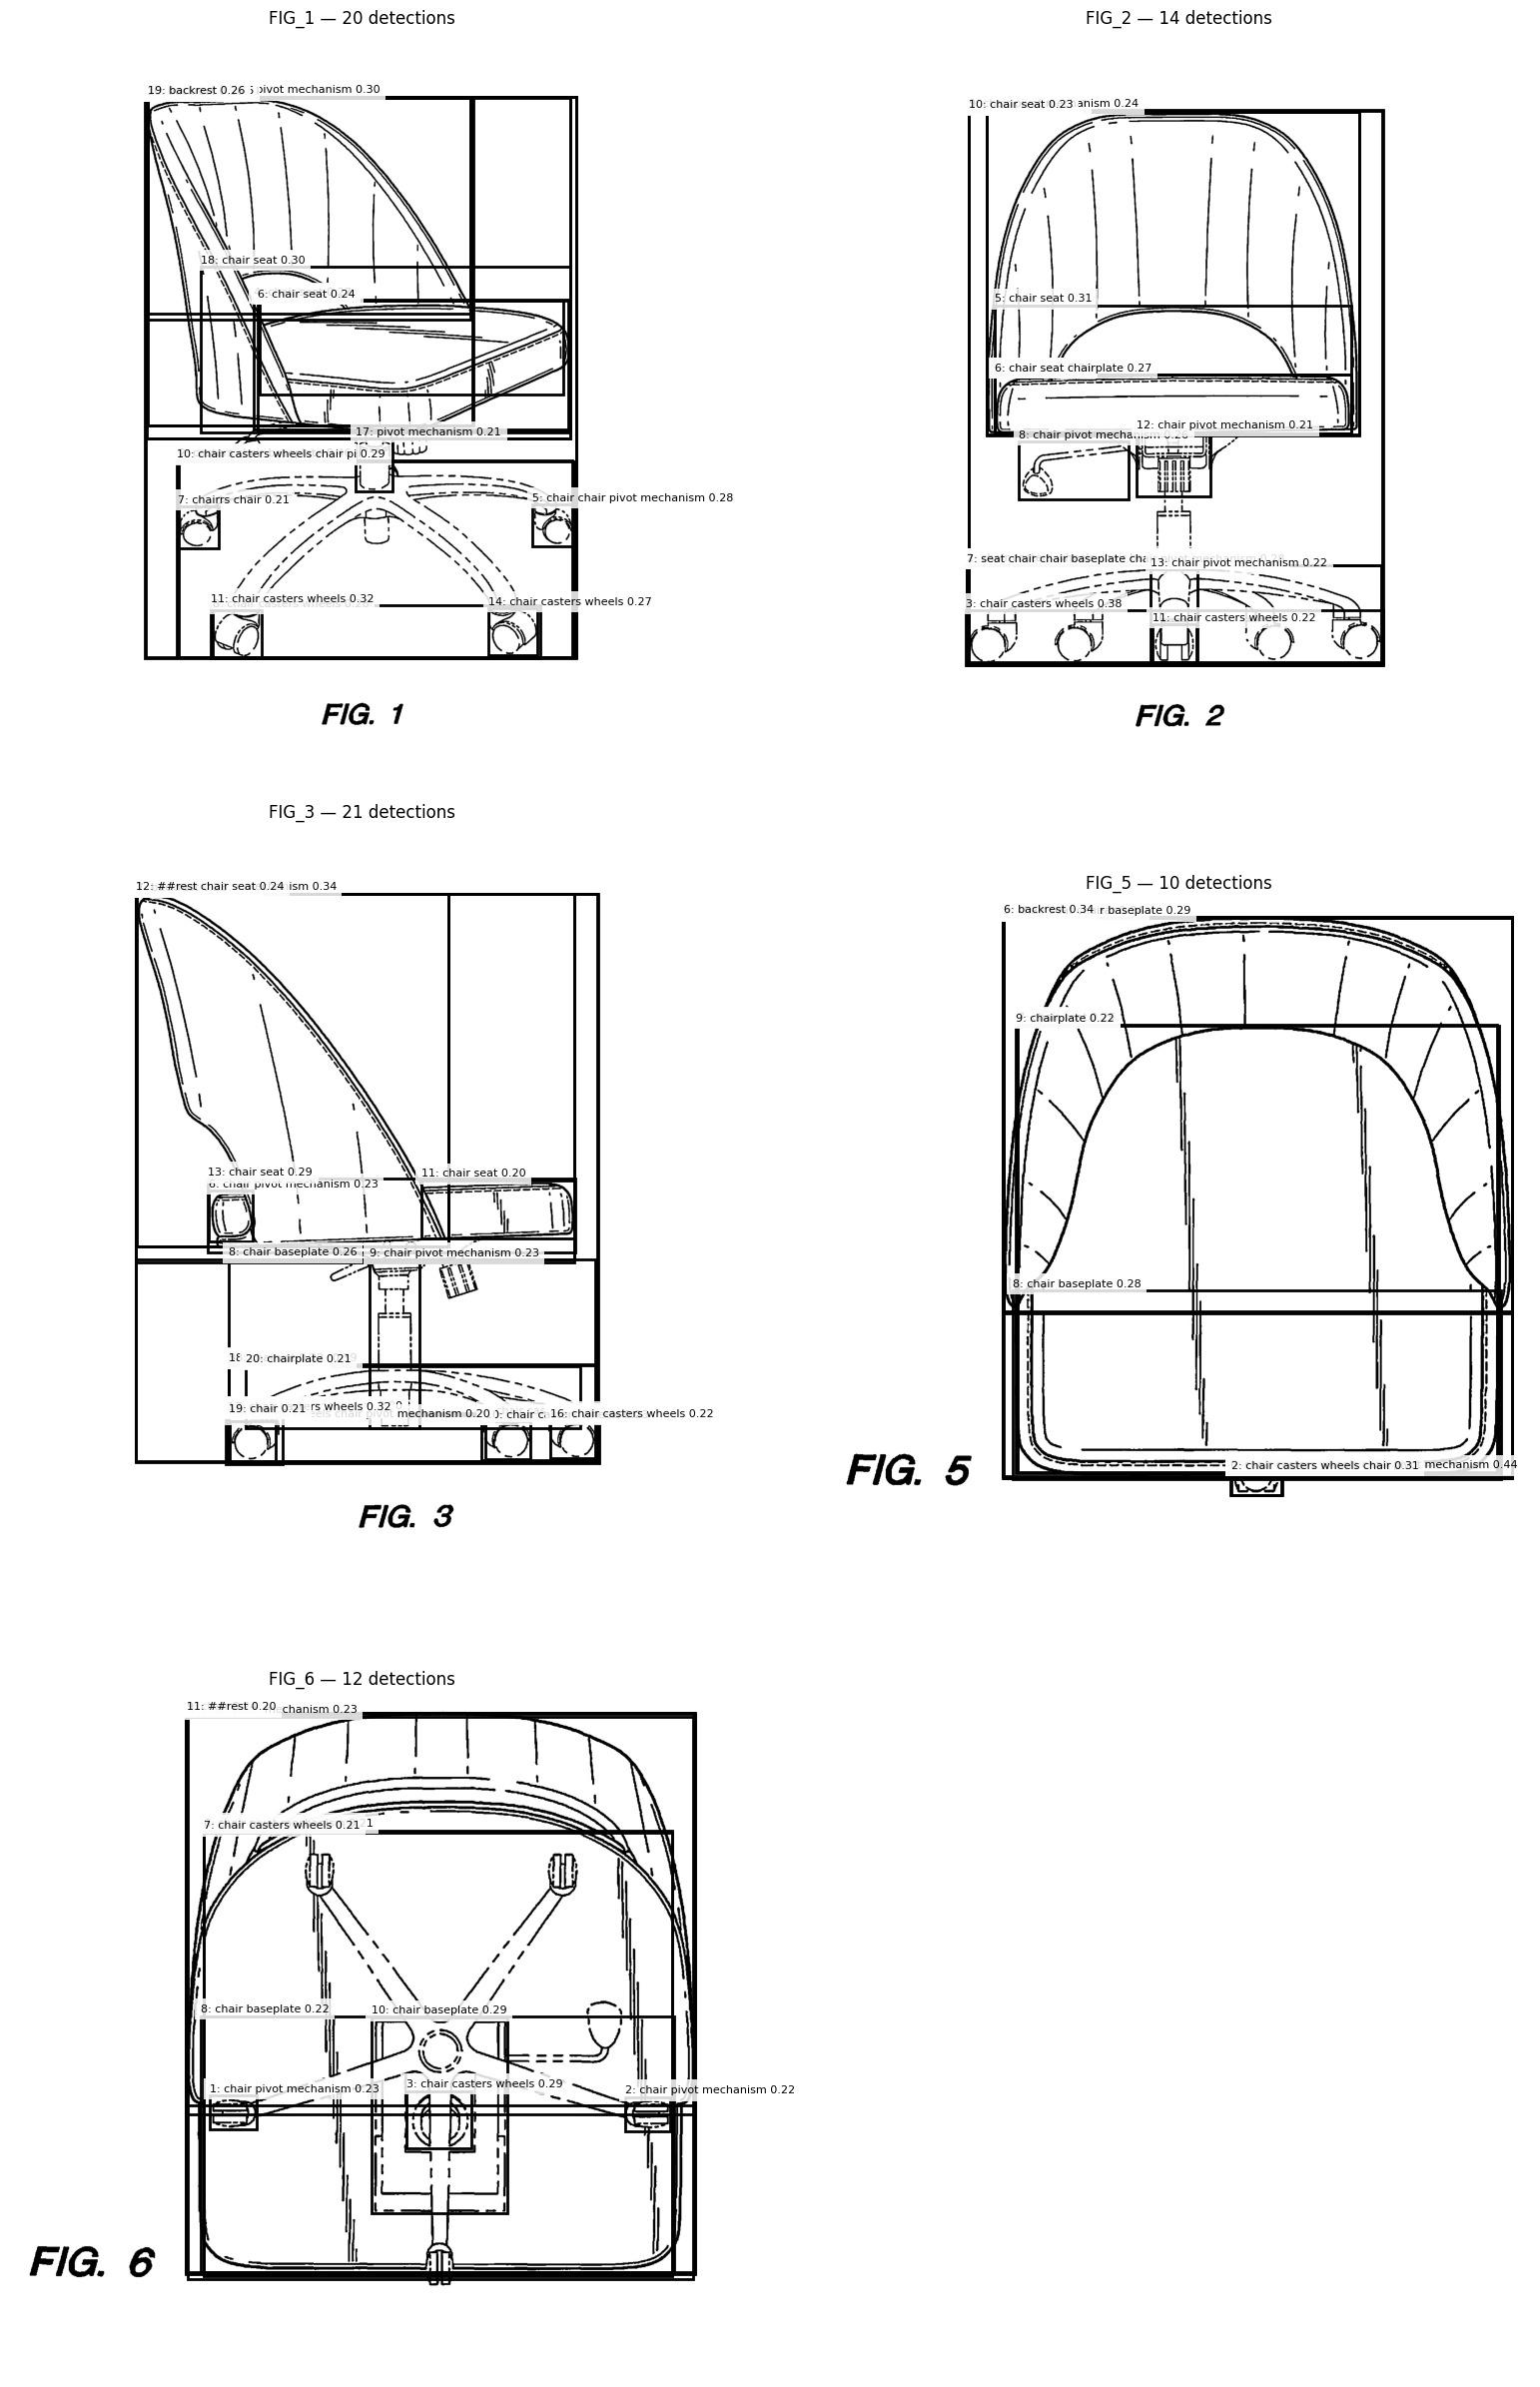

In [88]:
chair_keywords = ['chair backrest', 'chair seat', 'chair casters wheels', 'chair baseplate', 'chair pivot mechanism']
# chair_keywords = ['chair seat', 'chair backrest', 'chair legs', 'chair smiley face', 'chair holes', 'chair straps']

gdino_results = detect_keywords_with_grounding_dino(
    image_paths=crops,
    keywords=chair_keywords,
    box_threshold=0.20,
    text_threshold=0.18,
    cols=2,
)

# Create a Patent Graph

## Imports and Helper Functions


In [64]:
import re

import matplotlib.pyplot as plt
import networkx as nx

In [65]:
def bbox_area(bbox):
    x1, y1, x2, y2 = bbox
    return max(0, x2 - x1) * max(0, y2 - y1)


def bbox_contains(
    outer_bbox,
    inner_bbox,
    tolerance=0,
    require_strict=True,
    minimum_area_ratio=1.05,
):
    """
    outer_bbox must be at least minimum_area_ratio times larger
    than inner_bbox to qualify as its parent.
    """
    ox1, oy1, ox2, oy2 = outer_bbox
    ix1, iy1, ix2, iy2 = inner_bbox

    contained = (
        ix1 >= ox1 - tolerance
        and iy1 >= oy1 - tolerance
        and ix2 <= ox2 + tolerance
        and iy2 <= oy2 + tolerance
    )

    if not contained:
        return False

    outer_area = bbox_area(outer_bbox)
    inner_area = bbox_area(inner_bbox)

    if inner_area == 0:
        return False

    if require_strict and outer_area <= inner_area:
        return False

    area_ratio = outer_area / inner_area

    return area_ratio >= minimum_area_ratio

def bbox_iou(box_a, box_b):
    """
    Calculate intersection-over-union for two boxes:
    (x1, y1, x2, y2)
    """
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    intersection_x1 = max(ax1, bx1)
    intersection_y1 = max(ay1, by1)
    intersection_x2 = min(ax2, bx2)
    intersection_y2 = min(ay2, by2)

    intersection_width = max(
        0,
        intersection_x2 - intersection_x1,
    )
    intersection_height = max(
        0,
        intersection_y2 - intersection_y1,
    )

    intersection_area = (
        intersection_width * intersection_height
    )

    area_a = bbox_area(box_a)
    area_b = bbox_area(box_b)

    union_area = area_a + area_b - intersection_area

    if union_area <= 0:
        return 0.0

    return intersection_area / union_area

In [66]:
def normalize_detection_label(label):
    label = str(label).lower()
    label = label.replace("##", "")
    label = re.sub(r"\s+", " ", label).strip()

    words = label.split()
    cleaned_words = []

    for word in words:
        if not cleaned_words or cleaned_words[-1] != word:
            cleaned_words.append(word)

    return " ".join(cleaned_words)


def extract_known_keywords(
    detection_label,
    known_keywords,
):
    """
    Match a GDINO detection label against the keywords already
    present in the figure prompt.
    """
    label = normalize_detection_label(
        detection_label
    )

    matched = []

    # Check longer keywords first.
    sorted_keywords = sorted(
        known_keywords,
        key=len,
        reverse=True,
    )

    for keyword in sorted_keywords:
        normalized_keyword = normalize_detection_label(
            keyword
        )

        if normalized_keyword in label:
            matched.append(normalized_keyword)

    return list(dict.fromkeys(matched))

def get_detection_keywords(
    detection,
    known_keywords,
):
    raw_label = detection.get("label", "")

    matched_keywords = extract_known_keywords(
        detection_label=raw_label,
        known_keywords=known_keywords,
    )

    if matched_keywords:
        return set(matched_keywords)

    normalized = normalize_detection_label(raw_label)

    if normalized:
        return {normalized}

    return set()

In [67]:
def remove_duplicate_detections(
    detections,
    known_keywords,
    iou_threshold=0.85,
    require_keyword_overlap=True,
):
    """
    Remove highly overlapping duplicate detections.

    The highest-confidence box is kept first.

    Parameters
    ----------
    iou_threshold:
        Boxes with IoU greater than this value are considered
        duplicates.

    require_keyword_overlap:
        If True, overlapping boxes are removed only when their
        keyword sets overlap.
    """
    sorted_detections = sorted(
        detections,
        key=lambda detection: float(
            detection.get("score", 0.0)
        ),
        reverse=True,
    )

    kept_detections = []

    for candidate in sorted_detections:
        candidate_bbox = tuple(candidate["bbox"])

        candidate_keywords = get_detection_keywords(
            candidate,
            known_keywords,
        )

        is_duplicate = False

        for kept in kept_detections:
            kept_bbox = tuple(kept["bbox"])

            overlap = bbox_iou(
                candidate_bbox,
                kept_bbox,
            )

            if overlap < iou_threshold:
                continue

            if require_keyword_overlap:
                kept_keywords = get_detection_keywords(
                    kept,
                    known_keywords,
                )

                keyword_overlap = bool(
                    candidate_keywords & kept_keywords
                )

                if not keyword_overlap:
                    continue

            is_duplicate = True
            break

        if not is_duplicate:
            kept_detections.append(candidate)

    return kept_detections

In [68]:
def bbox_contains_with_ratio(
    outer_bbox,
    inner_bbox,
    tolerance=2,
    minimum_area_ratio=1.10,
):
    """
    Return True when inner_bbox is contained by outer_bbox.

    minimum_area_ratio prevents nearly identical boxes from
    producing unnecessary parent-child chains.
    """
    ox1, oy1, ox2, oy2 = outer_bbox
    ix1, iy1, ix2, iy2 = inner_bbox

    contained = (
        ix1 >= ox1 - tolerance
        and iy1 >= oy1 - tolerance
        and ix2 <= ox2 + tolerance
        and iy2 <= oy2 + tolerance
    )

    if not contained:
        return False

    outer_area = bbox_area(outer_bbox)
    inner_area = bbox_area(inner_bbox)

    if inner_area <= 0 or outer_area <= inner_area:
        return False

    return outer_area / inner_area >= minimum_area_ratio


def find_bbox_parents_with_ratio(
    detections,
    tolerance=2,
    minimum_area_ratio=1.10,
):
    """
    For each bounding box, select the smallest valid containing
    bounding box as its direct parent.
    """
    parent_map = {}

    for child in detections:
        child_id = child["id"]
        child_bbox = tuple(child["bbox"])

        possible_parents = []

        for candidate in detections:
            if candidate["id"] == child_id:
                continue

            candidate_bbox = tuple(candidate["bbox"])

            if bbox_contains_with_ratio(
                outer_bbox=candidate_bbox,
                inner_bbox=child_bbox,
                tolerance=tolerance,
                minimum_area_ratio=minimum_area_ratio,
            ):
                possible_parents.append(candidate)

        if not possible_parents:
            parent_map[child_id] = None
            continue

        direct_parent = min(
            possible_parents,
            key=lambda item: bbox_area(item["bbox"]),
        )

        parent_map[child_id] = direct_parent["id"]

    return parent_map

In [69]:
def find_bbox_parents(detections, tolerance=0):
    """
    Determine the direct parent of each bounding box.

    Returns:
        {
            child_detection_id: parent_detection_id | None
        }
    """
    valid_detections = [
        detection
        for detection in detections
        if detection.get("bbox") is not None
        and len(detection["bbox"]) == 4
    ]

    parent_map = {}

    for child in valid_detections:
        child_id = child["id"]
        child_bbox = tuple(child["bbox"])

        possible_parents = []

        for candidate_parent in valid_detections:
            parent_id = candidate_parent["id"]

            if parent_id == child_id:
                continue

            parent_bbox = tuple(candidate_parent["bbox"])

            if bbox_contains(
                outer_bbox=parent_bbox,
                inner_bbox=child_bbox,
                tolerance=tolerance,
                require_strict=True,
                minimum_area_ratio=1.1,
            ):
                possible_parents.append(candidate_parent)

        if not possible_parents:
            parent_map[child_id] = None
            continue

        # The nearest parent is the smallest box that contains the child.
        direct_parent = min(
            possible_parents,
            key=lambda detection: bbox_area(tuple(detection["bbox"])),
        )

        parent_map[child_id] = direct_parent["id"]

    return parent_map

## Build the Complete Patent Graph

In [70]:
import re
import networkx as nx
from pathlib import Path
from PIL import Image


def build_patent_detection_graph(
    patent_title: str,
    gdino_output: dict,
    score_threshold: float = 0.20,
    containment_tolerance: int = 0,
):
    """
    Graph structure:

        patent title
            ↓
        figure
            ↓
        top-level bounding box
            ↓
        nested bounding box
            ↓
        keyword

    Bounding boxes share keyword nodes across figures.
    Bounding-box nodes also store a cropped PIL image (crop_image)
    so the graph can be drawn with real crops instead of circles.
    """
    graph = nx.DiGraph()

    root_id = f"title::{patent_title}"

    # Needed to filter out keywords that are just the title
    # (e.g. GDINO detecting "chair" on a patent titled "Chair").
    normalized_title = normalize_detection_label(patent_title)

    graph.add_node(
        root_id,
        node_type="title",
        display_label=patent_title,
    )

    for figure_name, figure_data in gdino_output.items():
        figure_id = f"figure::{figure_name}"
        image_path = figure_data.get("image_path")

        graph.add_node(
            figure_id,
            node_type="figure",
            display_label=figure_name,
            image_path=image_path,
        )

        graph.add_edge(
            root_id,
            figure_id,
            edge_type="contains_figure",
        )

        # Load the source image once per figure so we can crop bboxes.
        source_image = None
        image_width = image_height = None

        if image_path and Path(image_path).exists():
            source_image = Image.open(image_path).convert("RGB")
            image_width, image_height = source_image.size

        # Keep only detections above the threshold.
        detections = [
            detection.copy()
            for detection in figure_data.get("detections", [])
            if float(detection.get("score", 0.0))
            >= score_threshold
        ]

        # Clip bboxes to image bounds and drop degenerate boxes,
        # same as the single-figure version does.
        if source_image is not None:
            valid_detections = []

            for detection in detections:
                if "bbox" not in detection:
                    continue

                x1, y1, x2, y2 = map(int, detection["bbox"])

                x1 = max(0, min(x1, image_width))
                y1 = max(0, min(y1, image_height))
                x2 = max(0, min(x2, image_width))
                y2 = max(0, min(y2, image_height))

                if x2 <= x1 or y2 <= y1:
                    continue

                detection["bbox"] = (x1, y1, x2, y2)
                valid_detections.append(detection)

            detections = valid_detections

        known_keywords = [
            keyword.strip().lower()
            for keyword in figure_data.get(
                "prompt",
                "",
            ).split(".")
            if keyword.strip()
        ]

        # Never treat the title itself as a valid keyword.
        # known_keywords = [
        #     keyword
        #     for keyword in known_keywords
        #     if normalize_detection_label(keyword) != normalized_title
        # ]

        detections = remove_duplicate_detections(
            detections=detections,
            known_keywords=known_keywords,
            iou_threshold=0.80,
            require_keyword_overlap=False,
        )

        # -------------------------------------------------
        # 1. Add every bounding-box node first
        # -------------------------------------------------
        for detection in detections:
            detection_id = detection["id"]
            bbox = tuple(detection["bbox"])
            score = float(detection.get("score", 0.0))
            raw_label = detection.get("label", "")

            bbox_id = (
                f"bbox::{figure_name}::{detection_id}"
            )

            crop_image = None
            if source_image is not None:
                crop_image = source_image.crop(bbox)

            graph.add_node(
                bbox_id,
                node_type="bbox",
                display_label=(
                    f"Box {detection_id}\n"
                    f"{score:.2f}\n"
                    f"{bbox}"
                ),
                figure=figure_name,
                detection_id=detection_id,
                bbox=bbox,
                bbox_area=bbox_area(bbox),
                score=score,
                raw_label=raw_label,
                crop_image=crop_image,
            )

        # -------------------------------------------------
        # 2. Calculate containment hierarchy
        # -------------------------------------------------
        parent_map = find_bbox_parents(
            detections=detections,
            tolerance=containment_tolerance,
        )

        for detection in detections:
            detection_id = detection["id"]
            bbox_id = (
                f"bbox::{figure_name}::{detection_id}"
            )

            parent_detection_id = parent_map[detection_id]

            if parent_detection_id is None:
                # No containing box: direct child of figure.
                graph.add_edge(
                    figure_id,
                    bbox_id,
                    edge_type="contains_top_level_bbox",
                )
            else:
                parent_bbox_id = (
                    f"bbox::{figure_name}::"
                    f"{parent_detection_id}"
                )

                graph.add_edge(
                    parent_bbox_id,
                    bbox_id,
                    edge_type="contains_bbox",
                )

        # -------------------------------------------------
        # 3. Connect boxes to shared keyword nodes
        # -------------------------------------------------
        # Connect bounding boxes to keywords.
        for detection in detections:
            detection_id = detection["id"]
            raw_label = str(detection.get("label", ""))
            score = float(detection.get("score", 0.0))

            bbox_node = f"bbox::{figure_name}::{detection_id}"

            matched_keywords = extract_known_keywords(
                detection_label=raw_label,
                known_keywords=known_keywords,
            )

            # Use the cleaned raw label only when no known keyword matches.
            if not matched_keywords:
                cleaned_label = normalize_detection_label(raw_label)

                if (
                    cleaned_label
                    and cleaned_label != normalized_title
                ):
                    matched_keywords = [cleaned_label]

            # Final safeguard against title keywords.
            # matched_keywords = [
            #     keyword
            #     for keyword in matched_keywords
            #     if normalize_detection_label(keyword) != normalized_title
            # ]

            for keyword in matched_keywords:
                keyword_node = f"keyword::{keyword}"

                if keyword_node not in graph:
                    graph.add_node(
                        keyword_node,
                        node_type="keyword",
                        display_label=keyword,
                    )

                graph.add_edge(
                    bbox_node,
                    keyword_node,
                    edge_type="classified_as",
                    score=score,
                )

    return graph


In [71]:
graph = build_patent_detection_graph(
    patent_title=title,
    gdino_output=gdino_results,
    score_threshold=0.20,
    containment_tolerance=20,
)

print("Nodes:", graph.number_of_nodes())
print("Edges:", graph.number_of_edges())

Nodes: 42
Edges: 63


## Visualization

In [72]:
def get_bbox_depths(graph):
    """
    Depth of each bbox node, measured from its figure's top-level boxes.
    Top-level boxes (direct children of a figure node) are depth 0;
    their children are depth 1, grandchildren depth 2, etc.
    """
    depths = {}

    figure_nodes = [
        node
        for node, attrs in graph.nodes(data=True)
        if attrs.get("node_type") == "figure"
    ]

    def assign_depth(node, depth):
        depths[node] = depth
        for child in graph.successors(node):
            if graph.nodes[child].get("node_type") != "bbox":
                continue
            edge_type = graph.edges[node, child].get("edge_type")
            if edge_type != "contains_bbox":
                continue
            assign_depth(child, depth + 1)

    for figure_node in figure_nodes:
        for child in graph.successors(figure_node):
            if graph.nodes[child].get("node_type") != "bbox":
                continue
            edge_type = graph.edges[figure_node, child].get("edge_type")
            if edge_type != "contains_top_level_bbox":
                continue
            assign_depth(child, 0)

    return depths

In [73]:
def create_layered_positions(graph):
    """
    Layout:

        title
        figures
        top-level bounding boxes
        child bounding boxes
        grandchild bounding boxes
        ...
        keywords
    """
    positions = {}

    title_nodes = []
    figure_nodes = []
    keyword_nodes = []

    for node, attrs in graph.nodes(data=True):
        node_type = attrs.get("node_type")

        if node_type == "title":
            title_nodes.append(node)
        elif node_type == "figure":
            figure_nodes.append(node)
        elif node_type == "keyword":
            keyword_nodes.append(node)

    bbox_depths = get_bbox_depths(graph)

    bbox_nodes_by_depth = {}

    for node, depth in bbox_depths.items():
        bbox_nodes_by_depth.setdefault(depth, []).append(node)

    max_bbox_depth = max(
        bbox_depths.values(),
        default=0,
    )

    # Fixed vertical levels
    title_y = max_bbox_depth + 3
    figure_y = max_bbox_depth + 2

    # Top-level bbox starts below figures.
    bbox_y = {
        depth: max_bbox_depth + 1 - depth
        for depth in range(max_bbox_depth + 1)
    }

    keyword_y = -1

    def assign_horizontal_positions(nodes, y):
        nodes = sorted(nodes)
        count = len(nodes)

        if count == 0:
            return

        if count == 1:
            x_values = [0.0]
        else:
            x_values = [
                index - (count - 1) / 2
                for index in range(count)
            ]

        for node, x in zip(nodes, x_values):
            positions[node] = (x, y)

    assign_horizontal_positions(
        title_nodes,
        title_y,
    )

    assign_horizontal_positions(
        figure_nodes,
        figure_y,
    )

    for depth, nodes in sorted(
        bbox_nodes_by_depth.items()
    ):
        assign_horizontal_positions(
            nodes,
            bbox_y[depth],
        )

    assign_horizontal_positions(
        keyword_nodes,
        keyword_y,
    )

    return positions

In [74]:
from matplotlib.offsetbox import AnnotationBbox, OffsetImage


def draw_patent_detection_graph(
    graph,
    figsize=(32, 20),
    crop_zoom=0.10,
):
    positions = create_layered_positions(graph)

    fig, ax = plt.subplots(figsize=figsize)

    node_styles = {
        "title": {
            "node_size": 5000,
            "node_shape": "s",
        },
        "figure": {
            "node_size": 3500,
            "node_shape": "s",
        },
        "keyword": {
            "node_size": 3000,
            "node_shape": "D",
        },
    }

    # Title/figure/keyword nodes are still drawn as regular shapes.
    # Bbox nodes are drawn as image crops below instead of circles.
    for node_type, style in node_styles.items():
        selected_nodes = [
            node
            for node, attrs in graph.nodes(data=True)
            if attrs.get("node_type") == node_type
        ]

        nx.draw_networkx_nodes(
            graph,
            positions,
            nodelist=selected_nodes,
            node_size=style["node_size"],
            node_shape=style["node_shape"],
            alpha=0.9,
            ax=ax,
        )

    # Draw hierarchy edges separately.
    hierarchy_edges = [
        (source, target)
        for source, target, attrs
        in graph.edges(data=True)
        if attrs.get("edge_type") != "classified_as"
    ]

    keyword_edges = [
        (source, target)
        for source, target, attrs
        in graph.edges(data=True)
        if attrs.get("edge_type") == "classified_as"
    ]

    nx.draw_networkx_edges(
        graph,
        positions,
        edgelist=hierarchy_edges,
        arrows=True,
        arrowsize=12,
        width=1.2,
        alpha=0.7,
        ax=ax,
    )

    nx.draw_networkx_edges(
        graph,
        positions,
        edgelist=keyword_edges,
        arrows=True,
        arrowsize=9,
        width=0.6,
        alpha=0.3,
        connectionstyle="arc3,rad=0.04",
        ax=ax,
    )

    # Labels only for the non-bbox nodes; bbox nodes get a small
    # caption underneath their crop instead (see below).
    labels = {
        node: attrs.get("display_label", node)
        for node, attrs in graph.nodes(data=True)
        if attrs.get("node_type") != "bbox"
    }

    nx.draw_networkx_labels(
        graph,
        positions,
        labels=labels,
        font_size=6,
        ax=ax,
    )

    # Draw every bbox node as its cropped image instead of a circle.
    bbox_nodes = [
        node
        for node, attrs in graph.nodes(data=True)
        if attrs.get("node_type") == "bbox"
    ]

    for node in bbox_nodes:
        attrs = graph.nodes[node]
        x, y = positions[node]
        crop = attrs.get("crop_image")

        if crop is None:
            # Fall back to a plain marker if no image was available
            # (e.g. the source figure image couldn't be found on disk).
            nx.draw_networkx_nodes(
                graph,
                positions,
                nodelist=[node],
                node_size=2200,
                node_shape="o",
                alpha=0.9,
                ax=ax,
            )
            continue

        image_box = OffsetImage(crop, zoom=crop_zoom)

        annotation = AnnotationBbox(
            image_box,
            (x, y),
            frameon=True,
            pad=0.08,
            box_alignment=(0.5, 0.5),
            zorder=5,
        )

        ax.add_artist(annotation)

        score = attrs.get("score", 0.0)
        ax.annotate(
            f"{score:.2f}",
            xy=(x, y),
            xytext=(0, -26),
            textcoords="offset points",
            ha="center",
            va="top",
            fontsize=6,
            zorder=6,
        )

    ax.axis("off")
    fig.tight_layout()
    plt.show()


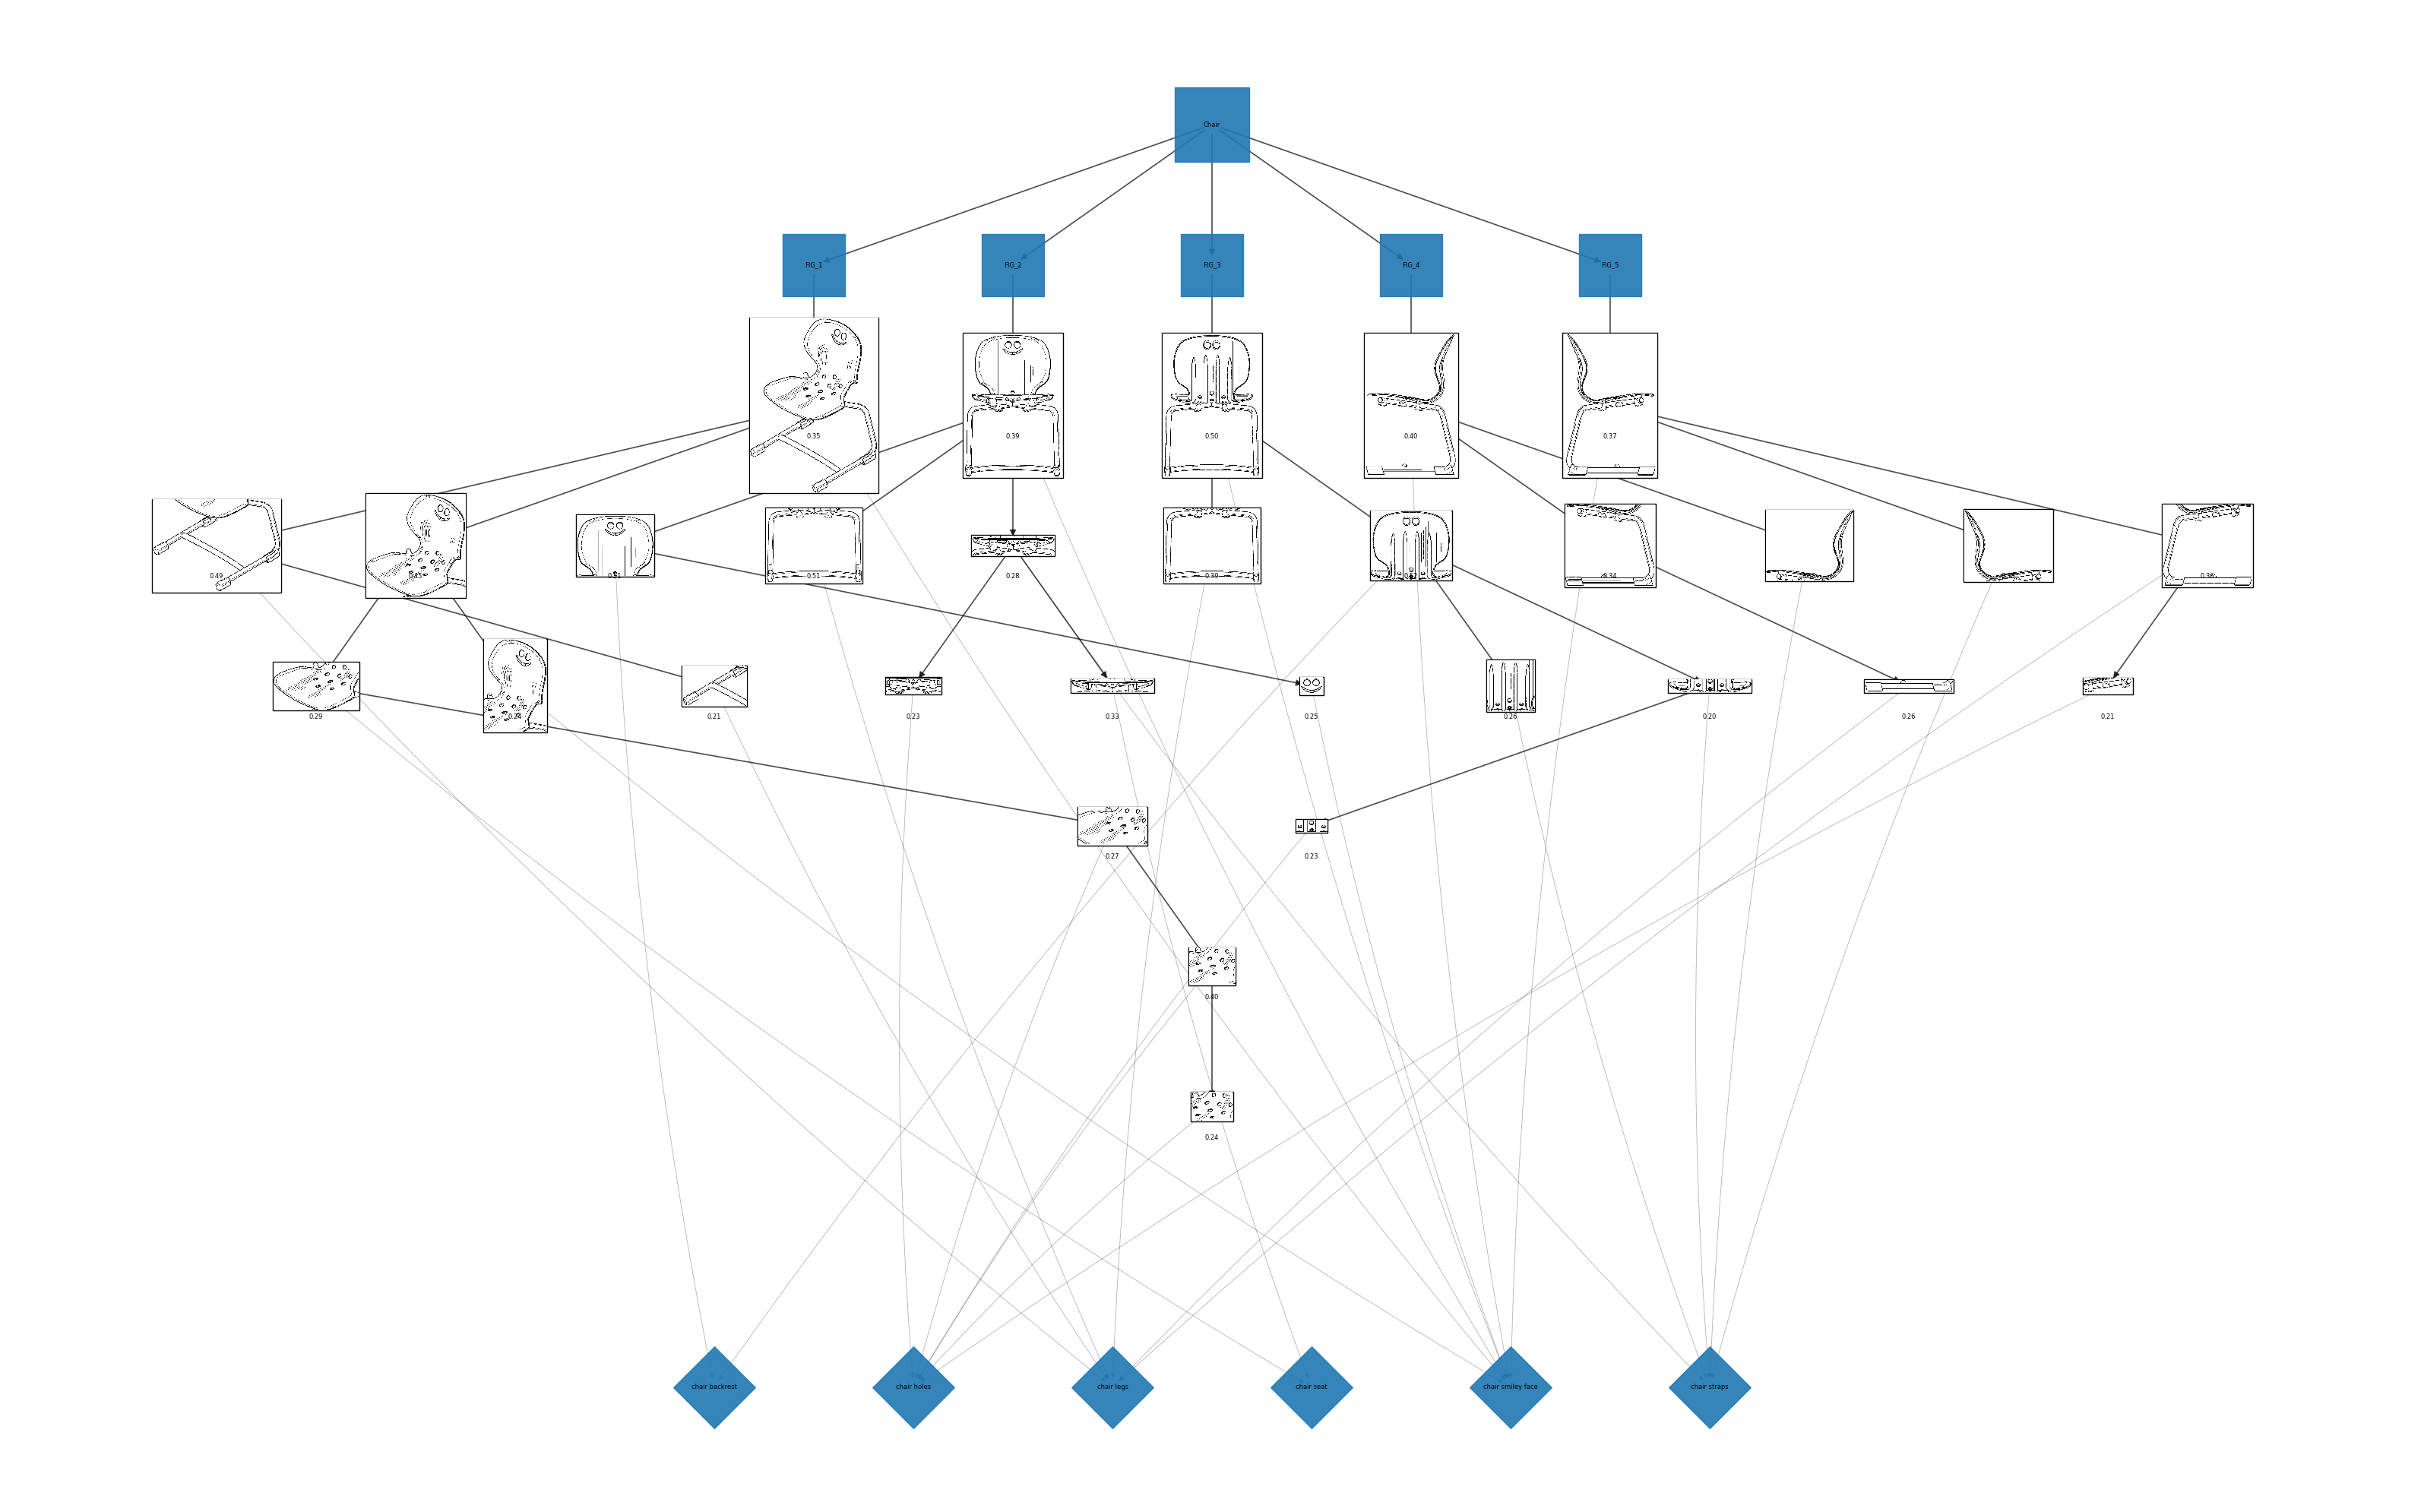

In [75]:
draw_patent_detection_graph(graph)

# Single Fig Tree View

In [89]:
def bbox_iou(box_a, box_b):
    """
    Calculate intersection-over-union for two boxes:
    (x1, y1, x2, y2)
    """
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    intersection_x1 = max(ax1, bx1)
    intersection_y1 = max(ay1, by1)
    intersection_x2 = min(ax2, bx2)
    intersection_y2 = min(ay2, by2)

    intersection_width = max(
        0,
        intersection_x2 - intersection_x1,
    )
    intersection_height = max(
        0,
        intersection_y2 - intersection_y1,
    )

    intersection_area = (
        intersection_width * intersection_height
    )

    area_a = bbox_area(box_a)
    area_b = bbox_area(box_b)

    union_area = area_a + area_b - intersection_area

    if union_area <= 0:
        return 0.0

    return intersection_area / union_area

In [90]:
def build_single_figure_crop_graph(
    gdino_output,
    figure_name,
    title,
    score_threshold=0.20,
    containment_tolerance=2,
    minimum_area_ratio=1.10,
):
    """
    Build a graph for one figure:

        figure -> bbox hierarchy -> shared keywords

    The graph stores the crop image for each bounding-box node.
    """
    if figure_name not in gdino_output:
        raise KeyError(
            f"{figure_name!r} is not present. "
            f"Available figures: {list(gdino_output.keys())}"
        )

    figure_data = gdino_output[figure_name]
    image_path = figure_data["image_path"]

    if not Path(image_path).exists():
        raise FileNotFoundError(
            f"Image does not exist: {image_path}"
        )

    source_image = Image.open(image_path).convert("RGB")
    image_width, image_height = source_image.size

    detections = [
        detection.copy()
        for detection in figure_data.get("detections", [])
        if float(detection.get("score", 0.0)) >= score_threshold
    ]

    # Ensure all bounding boxes are valid and remain inside the image.
    valid_detections = []

    for detection in detections:
        if "bbox" not in detection:
            continue

        x1, y1, x2, y2 = map(
            int,
            detection["bbox"],
        )

        x1 = max(0, min(x1, image_width))
        y1 = max(0, min(y1, image_height))
        x2 = max(0, min(x2, image_width))
        y2 = max(0, min(y2, image_height))

        if x2 <= x1 or y2 <= y1:
            continue

        detection["bbox"] = (x1, y1, x2, y2)
        valid_detections.append(detection)

    detections = valid_detections

    normalized_title = normalize_detection_label(title)

    known_keywords = [
        keyword.strip().lower()
        for keyword in figure_data.get("prompt", "").split(".")
        if keyword.strip()
    ]

    known_keywords = [
        keyword
        for keyword in known_keywords
        if normalize_detection_label(keyword) != normalized_title
    ]

    detections = remove_duplicate_detections(
        detections=detections,
        known_keywords=known_keywords,
        iou_threshold=0.80,
        require_keyword_overlap=False,
    )

    parent_map = find_bbox_parents_with_ratio(
        detections=detections,
        tolerance=containment_tolerance,
        minimum_area_ratio=minimum_area_ratio,
    )

    graph = nx.DiGraph()

    figure_node = f"figure::{figure_name}"

    graph.add_node(
        figure_node,
        node_type="figure",
        display_label=figure_name,
        image_path=image_path,
    )

    # Add bbox nodes with their cropped images.
    for detection in detections:
        detection_id = detection["id"]
        bbox = tuple(detection["bbox"])
        score = float(detection.get("score", 0.0))
        raw_label = str(detection.get("label", ""))

        bbox_node = f"bbox::{figure_name}::{detection_id}"

        crop = source_image.crop(bbox)

        graph.add_node(
            bbox_node,
            node_type="bbox",
            display_label=f"Box {detection_id}",
            figure=figure_name,
            detection_id=detection_id,
            bbox=bbox,
            score=score,
            raw_label=raw_label,
            crop_image=crop,
        )

    # Add containment hierarchy.
    for detection in detections:
        detection_id = detection["id"]
        bbox_node = f"bbox::{figure_name}::{detection_id}"

        parent_detection_id = parent_map[detection_id]

        if parent_detection_id is None:
            graph.add_edge(
                figure_node,
                bbox_node,
                edge_type="contains_top_level_bbox",
            )
        else:
            parent_node = (
                f"bbox::{figure_name}::{parent_detection_id}"
            )

            graph.add_edge(
                parent_node,
                bbox_node,
                edge_type="contains_bbox",
            )

    # Connect bounding boxes to the existing keywords.
    for detection in detections:
        detection_id = detection["id"]
        raw_label = str(detection.get("label", ""))
        score = float(detection.get("score", 0.0))

        bbox_node = f"bbox::{figure_name}::{detection_id}"

        matched_keywords = extract_known_keywords(
            detection_label=raw_label,
            known_keywords=known_keywords,
        )

        if not matched_keywords:
            cleaned_label = normalize_detection_label(raw_label)

            if (
                cleaned_label
                and cleaned_label != normalized_title
            ):
                matched_keywords = [cleaned_label]

        # Ensure the patent title itself is never added as a keyword.
        matched_keywords = [
            keyword
            for keyword in matched_keywords
            if normalize_detection_label(keyword) != normalized_title
        ]

        for keyword in matched_keywords:
            keyword_node = f"keyword::{keyword}"

            if keyword_node not in graph:
                graph.add_node(
                    keyword_node,
                    node_type="keyword",
                    display_label=keyword,
                )

            graph.add_edge(
                bbox_node,
                keyword_node,
                edge_type="classified_as",
                score=score,
            )

    return graph

In [91]:
def get_detection_keywords(
    detection,
    known_keywords,
):
    raw_label = detection.get("label", "")

    matched_keywords = extract_known_keywords(
        detection_label=raw_label,
        known_keywords=known_keywords,
    )

    if matched_keywords:
        return set(matched_keywords)

    normalized = normalize_detection_label(raw_label)

    if normalized:
        return {normalized}

    return set()

In [92]:
def bbox_area(bbox):
    x1, y1, x2, y2 = bbox
    return max(0, x2 - x1) * max(0, y2 - y1)


def bbox_contains_with_ratio(
    outer_bbox,
    inner_bbox,
    tolerance=2,
    minimum_area_ratio=1.10,
):
    """
    Return True when inner_bbox is contained by outer_bbox.

    minimum_area_ratio prevents nearly identical boxes from
    producing unnecessary parent-child chains.
    """
    ox1, oy1, ox2, oy2 = outer_bbox
    ix1, iy1, ix2, iy2 = inner_bbox

    contained = (
        ix1 >= ox1 - tolerance
        and iy1 >= oy1 - tolerance
        and ix2 <= ox2 + tolerance
        and iy2 <= oy2 + tolerance
    )

    if not contained:
        return False

    outer_area = bbox_area(outer_bbox)
    inner_area = bbox_area(inner_bbox)

    if inner_area <= 0 or outer_area <= inner_area:
        return False

    return outer_area / inner_area >= minimum_area_ratio


def find_bbox_parents_with_ratio(
    detections,
    tolerance=2,
    minimum_area_ratio=1.10,
):
    """
    For each bounding box, select the smallest valid containing
    bounding box as its direct parent.
    """
    parent_map = {}

    for child in detections:
        child_id = child["id"]
        child_bbox = tuple(child["bbox"])

        possible_parents = []

        for candidate in detections:
            if candidate["id"] == child_id:
                continue

            candidate_bbox = tuple(candidate["bbox"])

            if bbox_contains_with_ratio(
                outer_bbox=candidate_bbox,
                inner_bbox=child_bbox,
                tolerance=tolerance,
                minimum_area_ratio=minimum_area_ratio,
            ):
                possible_parents.append(candidate)

        if not possible_parents:
            parent_map[child_id] = None
            continue

        direct_parent = min(
            possible_parents,
            key=lambda item: bbox_area(item["bbox"]),
        )

        parent_map[child_id] = direct_parent["id"]

    return parent_map

In [93]:
def remove_duplicate_detections(
    detections,
    known_keywords,
    iou_threshold=0.85,
    require_keyword_overlap=True,
):
    """
    Remove highly overlapping duplicate detections.

    The highest-confidence box is kept first.

    Parameters
    ----------
    iou_threshold:
        Boxes with IoU greater than this value are considered
        duplicates.

    require_keyword_overlap:
        If True, overlapping boxes are removed only when their
        keyword sets overlap.
    """
    sorted_detections = sorted(
        detections,
        key=lambda detection: float(
            detection.get("score", 0.0)
        ),
        reverse=True,
    )

    kept_detections = []

    for candidate in sorted_detections:
        candidate_bbox = tuple(candidate["bbox"])

        candidate_keywords = get_detection_keywords(
            candidate,
            known_keywords,
        )

        is_duplicate = False

        for kept in kept_detections:
            kept_bbox = tuple(kept["bbox"])

            overlap = bbox_iou(
                candidate_bbox,
                kept_bbox,
            )

            if overlap < iou_threshold:
                continue

            if require_keyword_overlap:
                kept_keywords = get_detection_keywords(
                    kept,
                    known_keywords,
                )

                keyword_overlap = bool(
                    candidate_keywords & kept_keywords
                )

                if not keyword_overlap:
                    continue

            is_duplicate = True
            break

        if not is_duplicate:
            kept_detections.append(candidate)

    return kept_detections

In [94]:
def normalize_detection_label(label):
    label = str(label).lower()
    label = label.replace("##", "")
    label = re.sub(r"\s+", " ", label).strip()

    words = label.split()
    cleaned_words = []

    for word in words:
        if not cleaned_words or cleaned_words[-1] != word:
            cleaned_words.append(word)

    return " ".join(cleaned_words)


def extract_known_keywords(
    detection_label,
    known_keywords,
):
    """
    Match a GDINO detection label against the keywords already
    present in the figure prompt.
    """
    label = normalize_detection_label(
        detection_label
    )

    matched = []

    # Check longer keywords first.
    sorted_keywords = sorted(
        known_keywords,
        key=len,
        reverse=True,
    )

    for keyword in sorted_keywords:
        normalized_keyword = normalize_detection_label(
            keyword
        )

        if normalized_keyword in label:
            matched.append(normalized_keyword)

    return list(dict.fromkeys(matched))

In [95]:
def get_bbox_children(graph, node):
    return [
        child
        for child in graph.successors(node)
        if (
            graph.nodes[child].get("node_type") == "bbox"
            and graph.edges[node, child].get("edge_type")
            == "contains_bbox"
        )
    ]


def count_bbox_leaves(graph, node):
    """
    Count the number of leaf descendants under a bbox node.
    Used to reserve horizontal space for each subtree.
    """
    children = get_bbox_children(graph, node)

    if not children:
        return 1

    return sum(
        count_bbox_leaves(graph, child)
        for child in children
    )


def create_single_figure_crop_positions(graph):
    """
    Arrange the figure and its bbox containment trees.

    Keywords are placed below the deepest bbox level.
    """
    figure_nodes = [
        node
        for node, attrs in graph.nodes(data=True)
        if attrs.get("node_type") == "figure"
    ]

    if len(figure_nodes) != 1:
        raise ValueError(
            "The graph must contain exactly one figure node."
        )

    figure_node = figure_nodes[0]

    top_level_boxes = [
        node
        for node in graph.successors(figure_node)
        if graph.nodes[node].get("node_type") == "bbox"
    ]

    keyword_nodes = sorted(
        [
            node
            for node, attrs in graph.nodes(data=True)
            if attrs.get("node_type") == "keyword"
        ],
        key=lambda node: graph.nodes[node].get(
            "display_label",
            node,
        ),
    )

    positions = {}
    bbox_depths = {}

    def place_subtree(node, left, right, depth):
        x = (left + right) / 2
        y = -depth

        positions[node] = (x, y)
        bbox_depths[node] = depth

        children = get_bbox_children(graph, node)

        if not children:
            return

        total_leaves = sum(
            count_bbox_leaves(graph, child)
            for child in children
        )

        current_left = left

        for child in children:
            child_leaves = count_bbox_leaves(
                graph,
                child,
            )

            child_width = (
                (right - left)
                * child_leaves
                / total_leaves
            )

            child_right = current_left + child_width

            place_subtree(
                child,
                current_left,
                child_right,
                depth + 1,
            )

            current_left = child_right

    total_width = sum(
        count_bbox_leaves(graph, node)
        for node in top_level_boxes
    )

    total_width = max(total_width, 1)

    current_left = 0.0

    for node in top_level_boxes:
        subtree_width = count_bbox_leaves(
            graph,
            node,
        )

        right = current_left + subtree_width

        place_subtree(
            node,
            current_left,
            right,
            depth=1,
        )

        current_left = right

    center_x = total_width / 2
    positions[figure_node] = (center_x, 1)

    maximum_depth = max(
        bbox_depths.values(),
        default=1,
    )

    keyword_y = -(maximum_depth + 1.5)

    if keyword_nodes:
        keyword_spacing = max(
            total_width / max(len(keyword_nodes), 1),
            1.2,
        )

        keyword_total_width = (
            len(keyword_nodes) - 1
        ) * keyword_spacing

        keyword_start = (
            center_x - keyword_total_width / 2
        )

        for index, node in enumerate(keyword_nodes):
            positions[node] = (
                keyword_start + index * keyword_spacing,
                keyword_y,
            )

    return positions

In [96]:
def draw_single_figure_crop_graph(
    graph,
    figsize=(22, 14),
    crop_zoom=0.14,
    figure_node_size=4000,
    keyword_node_size=2800,
    show_bbox_info=True,
    save_path=None,
):
    """
    Draw one figure's graph.

    Bounding-box nodes are displayed as cropped images.
    """
    positions = create_single_figure_crop_positions(
        graph
    )

    figure_nodes = [
        node
        for node, attrs in graph.nodes(data=True)
        if attrs.get("node_type") == "figure"
    ]

    bbox_nodes = [
        node
        for node, attrs in graph.nodes(data=True)
        if attrs.get("node_type") == "bbox"
    ]

    keyword_nodes = [
        node
        for node, attrs in graph.nodes(data=True)
        if attrs.get("node_type") == "keyword"
    ]

    hierarchy_edges = [
        (source, target)
        for source, target, attrs
        in graph.edges(data=True)
        if attrs.get("edge_type") in {
            "contains_top_level_bbox",
            "contains_bbox",
        }
    ]

    keyword_edges = [
        (source, target)
        for source, target, attrs
        in graph.edges(data=True)
        if attrs.get("edge_type") == "classified_as"
    ]

    fig, ax = plt.subplots(figsize=figsize)

    # Hierarchy edges.
    nx.draw_networkx_edges(
        graph,
        positions,
        edgelist=hierarchy_edges,
        ax=ax,
        arrows=True,
        arrowsize=15,
        width=1.5,
        alpha=0.75,
        connectionstyle="arc3,rad=0.0",
    )

    # Keyword edges are lighter because there can be many.
    nx.draw_networkx_edges(
        graph,
        positions,
        edgelist=keyword_edges,
        ax=ax,
        arrows=True,
        arrowsize=10,
        width=0.8,
        alpha=0.30,
        connectionstyle="arc3,rad=0.08",
    )

    nx.draw_networkx_nodes(
        graph,
        positions,
        nodelist=figure_nodes,
        node_shape="s",
        node_size=figure_node_size,
        ax=ax,
    )

    nx.draw_networkx_nodes(
        graph,
        positions,
        nodelist=keyword_nodes,
        node_shape="D",
        node_size=keyword_node_size,
        ax=ax,
    )

    regular_labels = {}

    for node in figure_nodes + keyword_nodes:
        regular_labels[node] = graph.nodes[node].get(
            "display_label",
            node,
        )

    nx.draw_networkx_labels(
        graph,
        positions,
        labels=regular_labels,
        font_size=9,
        ax=ax,
    )

    # Draw every bbox crop at the corresponding graph position.
    for node in bbox_nodes:
        attrs = graph.nodes[node]
        x, y = positions[node]

        crop = attrs["crop_image"]

        image_box = OffsetImage(
            crop,
            zoom=crop_zoom,
        )

        annotation = AnnotationBbox(
            image_box,
            (x, y),
            frameon=True,
            pad=0.08,
            box_alignment=(0.5, 0.5),
            zorder=5,
        )

        ax.add_artist(annotation)

        if show_bbox_info:
            bbox_id = attrs.get("detection_id")
            score = attrs.get("score", 0.0)
            label = attrs.get("raw_label", "")

            caption = (
                f"Box {bbox_id} | {score:.2f}\n"
                f"{label}"
            )

            ax.annotate(
                caption,
                xy=(x, y),
                xytext=(0, -42),
                textcoords="offset points",
                ha="center",
                va="top",
                fontsize=6,
                zorder=6,
            )

    all_x = [
        coordinate[0]
        for coordinate in positions.values()
    ]

    all_y = [
        coordinate[1]
        for coordinate in positions.values()
    ]

    if all_x and all_y:
        ax.set_xlim(
            min(all_x) - 1,
            max(all_x) + 1,
        )

        ax.set_ylim(
            min(all_y) - 1,
            max(all_y) + 1,
        )

    ax.axis("off")
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=200,
            bbox_inches="tight",
        )

    plt.show()

    return fig, ax

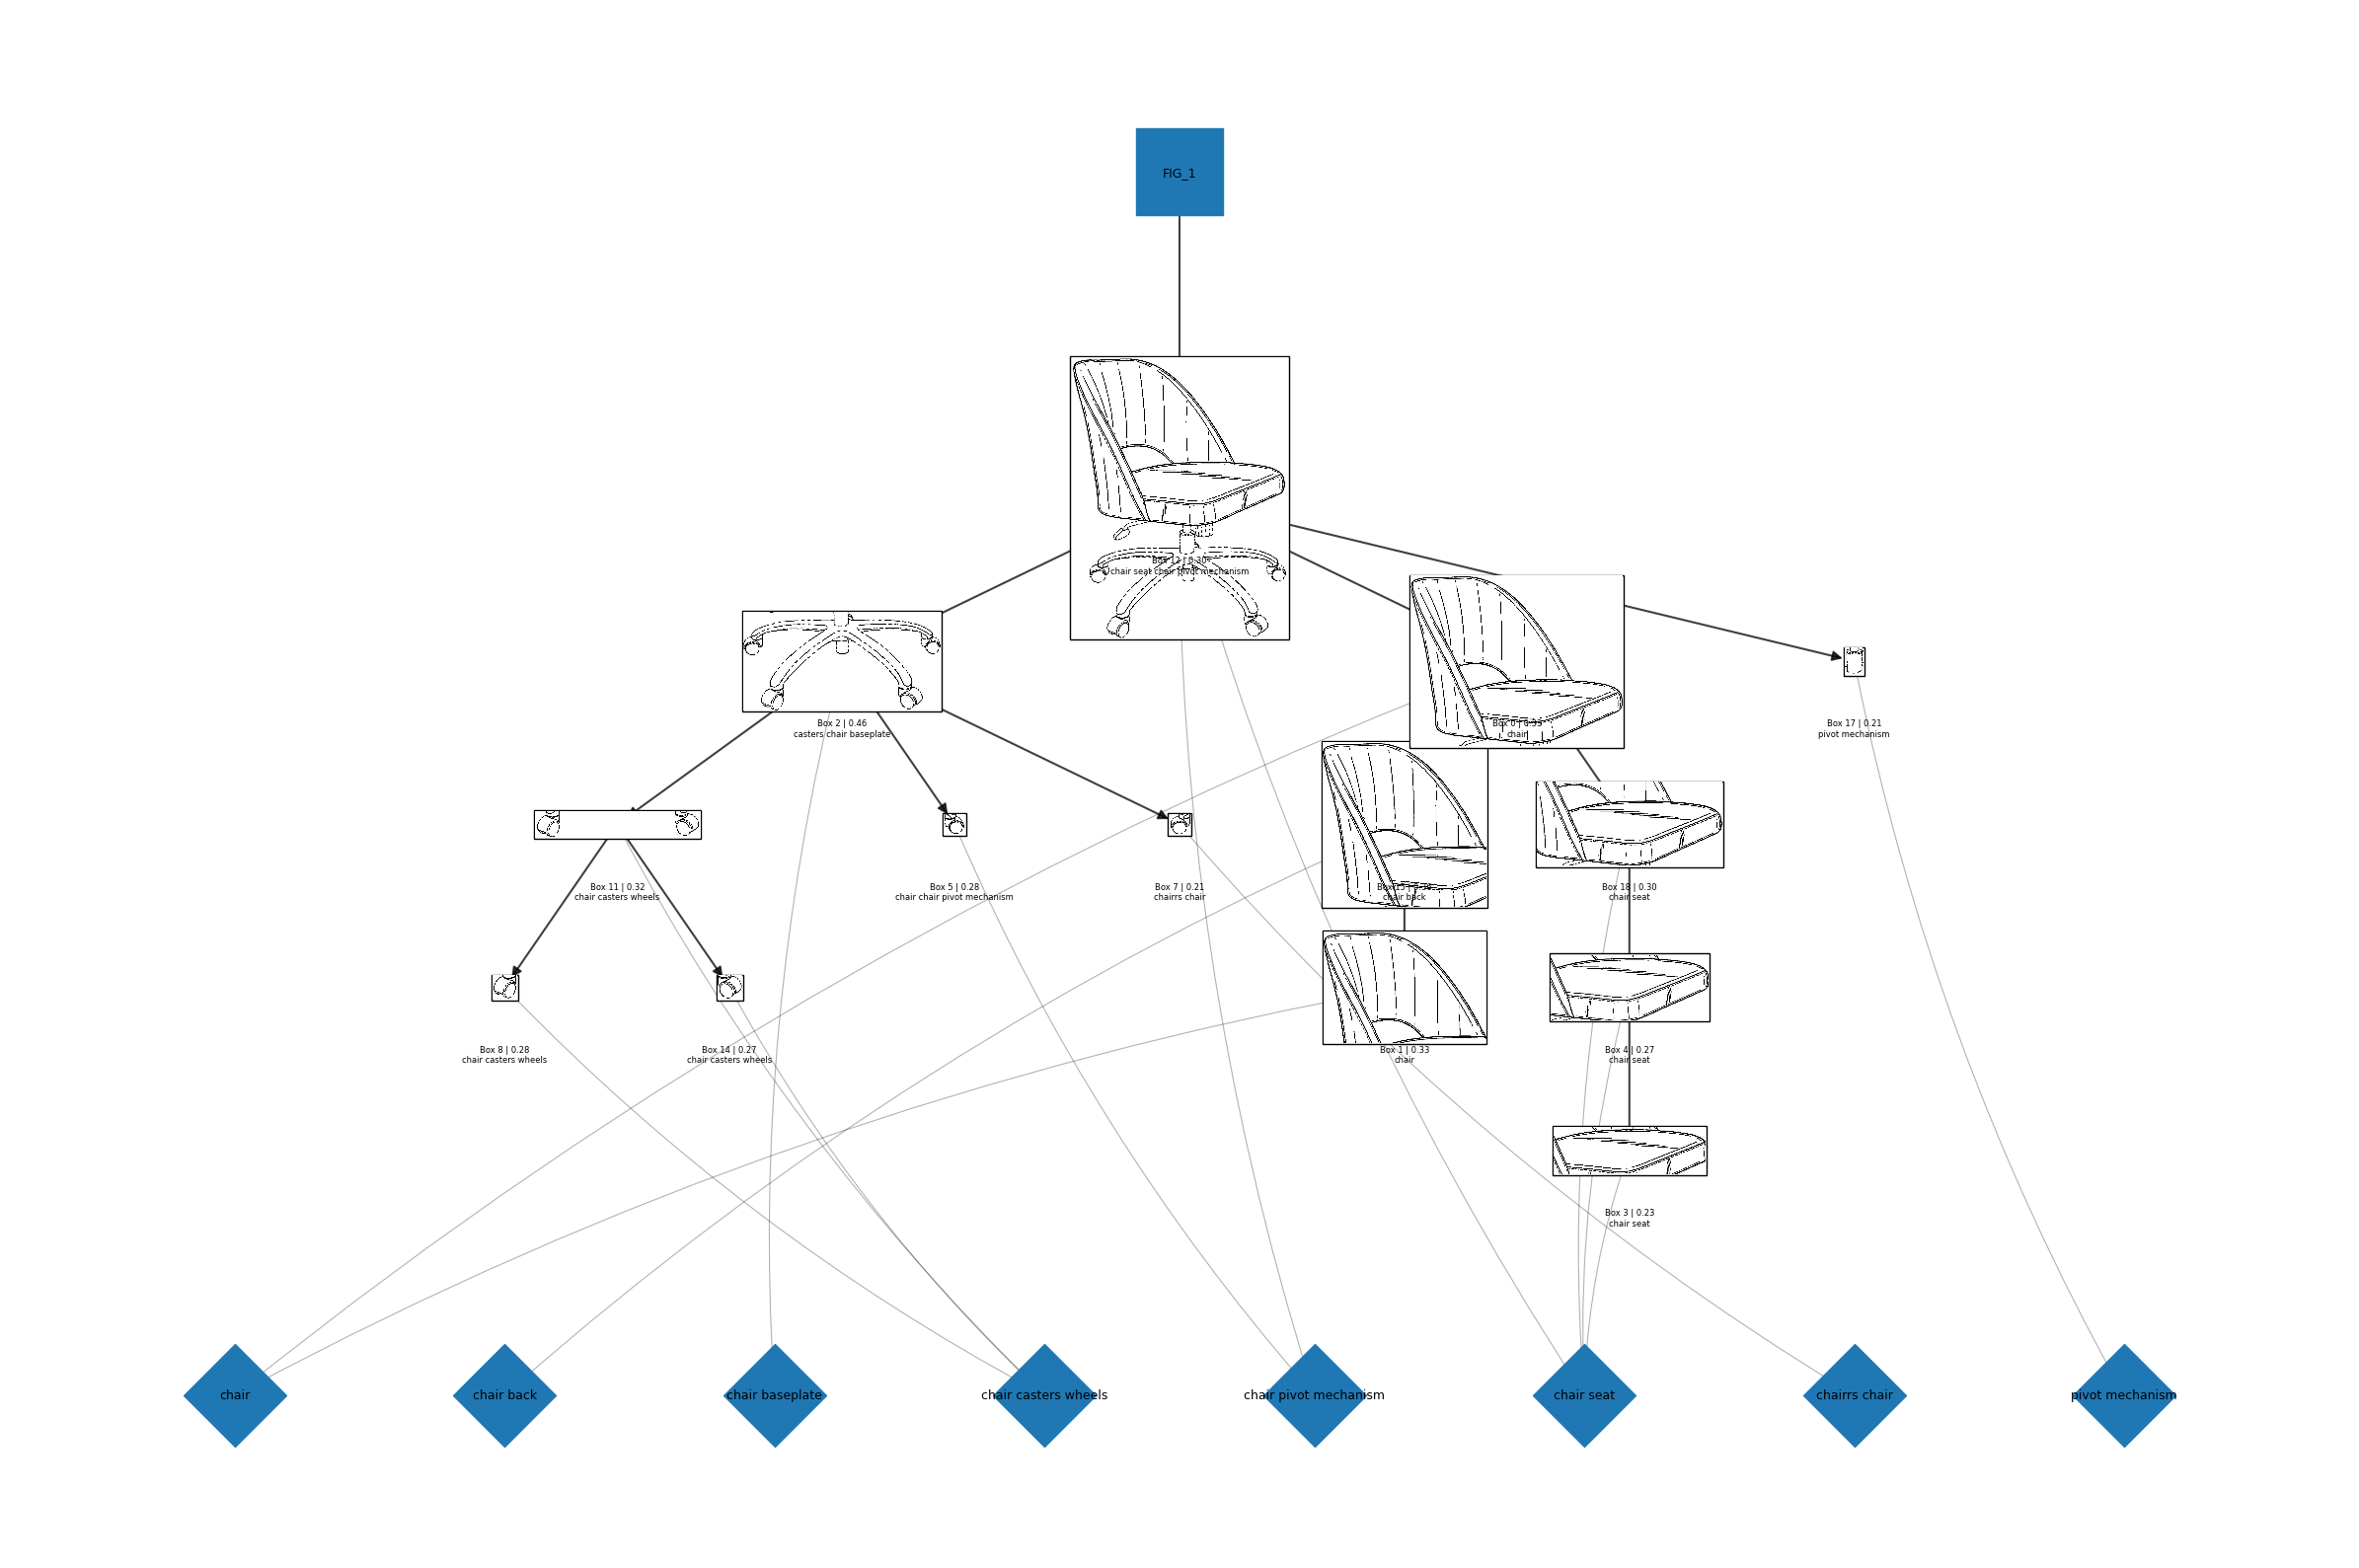

(<Figure size 2400x1600 with 1 Axes>, <Axes: >)

In [97]:
fig_graph = build_single_figure_crop_graph(
    gdino_output=gdino_results,
    figure_name="FIG_1",
    title=title,
    score_threshold=0.20,
    containment_tolerance=10,
    minimum_area_ratio=1.10,
)

draw_single_figure_crop_graph(
    graph=fig_graph,
    figsize=(24, 16),
    crop_zoom=0.12,
    show_bbox_info=True,
)